In [1]:
import torch
import numpy as np
from matplotlib import pyplot as plt
from typing import Tuple, Dict

/home/yl3836/.conda/envs/mevent/lib/python3.9/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from dataclasses import dataclass, asdict, is_dataclass

@dataclass
class BrownianConfig:
    height: int = 240       # H
    width: int = 346         # W
    frames: int = 30000        # T
    num_points: int = 20    # N
    fps: int = 1000        
    size: int = 15

    # Diffusion coefficients 
    D_xy: float = 500.0  # pixel^2/s
    D_z: float = 0.1    # depth_units^2/s

    # Depth range 
    depth_min: float = 0.0
    depth_max: float = 1.0

    # Random seed 
    seed: int = 50

In [3]:
def simulate_brownian_dataset(cfg: BrownianConfig) -> Dict[str, np.ndarray]:
    rng = np.random.default_rng(cfg.seed)
    H, W, T, N = cfg.height, cfg.width, cfg.frames, cfg.num_points
    dt = 1.0 / cfg.fps

    # Precompute per-step standard deviations (Var = 2 * D * dt)
    sigma_xy = np.sqrt(2.0 * cfg.D_xy * dt)
    sigma_z  = np.sqrt(2.0 * cfg.D_z  * dt)

    # Initialize continuous positions uniformly within bounds
    # (y, x) = (row, col)
    y = rng.uniform(0, H - 1, size=N)
    x = rng.uniform(0, W - 1, size=N)
    z = rng.uniform(cfg.depth_min, cfg.depth_max, size=N)

    # Storage
    frames = np.zeros((T, H, W), dtype=np.float)
    tracks = np.zeros((T, N, 2), dtype=np.int32)       # (y, x) integer pixels
    depths = np.ones((T, N), dtype=np.float)        # depth values per point


    def reflect(pos, lower, upper):
        """
        Reflecting boundary conditions for 1D coordinate array.
        For any values outside [lower, upper], reflect them back into range.
        """
        span = upper - lower
        pos = pos - lower
        pos = np.mod(pos, 2 * span)
        mask = pos > span
        pos[mask] = 2 * span - pos[mask]
        return pos + lower

    for t in range(T):
        # Rasterize current positions (round to nearest pixel index)
        yi = np.clip(np.rint(y).astype(int), 0, H - cfg.size)
        xi = np.clip(np.rint(x).astype(int), 0, W - cfg.size)

        # frames[t, yi, xi] = 1
        
        ###############################################
        ### Increasing the pixel size of each point ###

        for dy in range(cfg.size):   # 0, 1, 2
            for dx in range(cfg.size):
                y2 = np.clip(yi + dy, 0, H - 1)
                x2 = np.clip(xi + dx, 0, W - 1)
                frames[t, y2, x2] = 1

        tracks[t, :, 0] = yi
        tracks[t, :, 1] = xi
        depths[t] = z.astype(np.float32)

        # Advance positions with Gaussian steps (independent per axis)
        y = y + rng.normal(0.0, sigma_xy, size=N)
        x = x + rng.normal(0.0, sigma_xy, size=N)
        z = z + rng.normal(0.0, sigma_z,  size=N)

        # Reflect at boundaries
        y = reflect(y, 0.0, H - 1.0)
        x = reflect(x, 0.0, W - 1.0)
        z = reflect(z, cfg.depth_min, cfg.depth_max)

    cfg_dict = asdict(cfg) if is_dataclass(cfg) else vars(cfg)
    meta = {
        "config": cfg_dict,
        "description": "Binary frames with N=100 Brownian points at 1000 fps; tracks are integer (y,x); depths are floats per point."
    }
    return {"frames": frames, "tracks": tracks, "depths": depths, "meta": meta}

In [4]:
cfg = BrownianConfig() 
data = simulate_brownian_dataset(cfg)

In [ ]:

meta = data["meta"]
frames = data["frames"]
tracks = data["tracks"]
depths = data["depths"]

# 

dict_keys(['frames', 'tracks', 'depths', 'meta'])
{'height': 240, 'width': 346, 'frames': 30000, 'num_points': 20, 'fps': 1000, 'size': 15, 'D_xy': 500.0, 'D_z': 0.1, 'depth_min': 0.0, 'depth_max': 1.0, 'seed': 50}
(30000, 240, 346)
(30000, 20, 2)
(30000, 20)


In [6]:
tensor_frames = torch.from_numpy(frames)
tensor_depths = torch.from_numpy(depths)
tensor_tracks = torch.from_numpy(tracks)

In [7]:

# assumes you already have:
# tensor_frames : (T, H, W)  (only used for shape)
# tensor_tracks : (T, N, 2)  long/int  [y, x]  (top-left pixel of the 15×15 block)
# tensor_depths : (T, N)     float

#Depth c

T, H, W = tensor_frames.shape
device  = tensor_depths.device

# initialize like your code (background depth = 1.0)
tensor_depthmaps = torch.ones((T, H, W), dtype=tensor_depths.dtype, device=device)

size = 15
# precompute 15x15 offsets (top-left convention; for centered subtract size//2 below)
oy = torch.arange(size, device=device)
ox = torch.arange(size, device=device)
OY, OX = torch.meshgrid(oy, ox, indexing='ij')   # (size, size)
OY = OY.reshape(-1, 1)                           # (K, 1)
OX = OX.reshape(-1, 1)                           # (K, 1)
K = size * size

for t in range(T):
    # (N,)
    y = tensor_tracks[t, :, 0].to(device).long()
    x = tensor_tracks[t, :, 1].to(device).long()
    d = tensor_depths[t].to(device)              # (N,)

    # (K, N) coordinates for each point's 15×15 block
    Y = (y.unsqueeze(0) + OY).clamp_(0, H - 1)
    X = (x.unsqueeze(0) + OX).clamp_(0, W - 1)

    # flatten to 1D linear indices and broadcast depths
    lin  = (Y * W + X).reshape(-1)               # (K*N,)
    vals = d.expand(K, y.numel()).reshape(-1)    # (K*N,)

    # write into the frame (last write wins for overlaps)
    tensor_depthmaps[t].view(-1).index_copy_(0, lin, vals)


: 

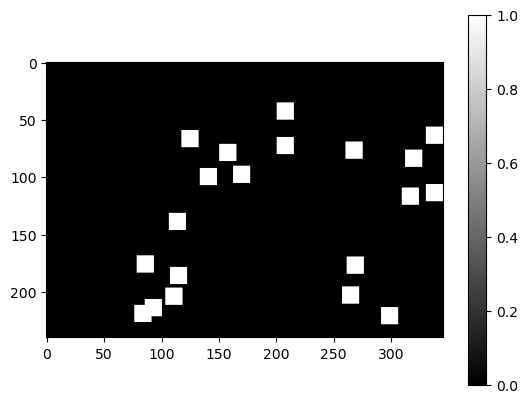

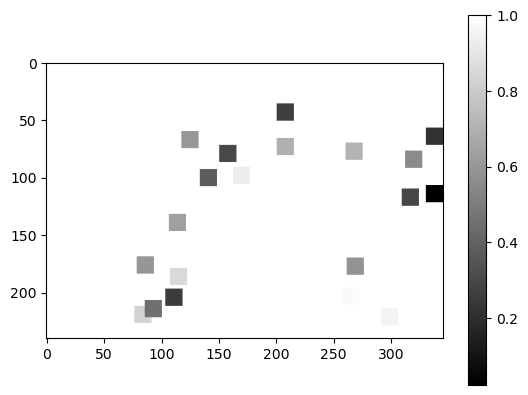

In [10]:
print(tensor_depthmaps.shape)

torch.Size([30000, 240, 346])


## Generating Dataset

In [7]:
import torch
import os
import imageio as imageio
from tqdm import tqdm

#save_dir = "/home/yl3836/DENSE/train_sparse_v2/train_seed_84/frames/"
save_dir = "/home/yl3836/DENSE/valid_sparse_v2/valid_seed_50/frames/"
os.makedirs(save_dir, exist_ok=True)

# tensor_depths가 (N, H, W) 또는 (N, 1, H, W) 형태일 경우 처리
#tensor_depths = tensor_depths.squeeze()

print(f"Saving {tensor_frames.shape[0]} frame images to {save_dir} ...")

for i in tqdm(range(tensor_frames.shape[0]), desc="Saving depth maps"):
    img = tensor_frames[i].cpu().numpy()
    #print(img.shape)
    filename = os.path.join(save_dir, f"{i:08d}.png")
    imageio.imwrite(filename, img)

print(f"✅ Done! Saved {tensor_frames.shape[0]} images to {save_dir}")


Saving 30000 frame images to /home/yl3836/DENSE/train_sparse_v2/train_seed_84/frames/ ...


Saving depth maps:   0%|          | 0/30000 [00:00<?, ?it/s]Lossy conversion from float64 to uint8. Range [0, 1]. Convert image to uint8 prior to saving to suppress this warning.


Saving depth maps:   0%|          | 1/30000 [00:00<54:18,  9.21it/s]Lossy conversion from float64 to uint8. Range [0, 1]. Convert image to uint8 prior to saving to suppress this warning.
Lossy conversion from float64 to uint8. Range [0, 1]. Convert image to uint8 prior to saving to suppress this warning.
Lossy conversion from float64 to uint8. Range [0, 1]. Convert image to uint8 prior to saving to suppress this warning.
Lossy conversion from float64 to uint8. Range [0, 1]. Convert image to uint8 prior to saving to suppress this warning.
Lossy conversion from float64 to uint8. Range [0, 1]. Convert image to uint8 prior to saving to suppress this warning.
Lossy conversion from float64 to uint8. Range [0, 1]. Convert image to uint8 prior to saving to suppress this warning.
Lossy conversion from float64 to uint8. Range [0, 1]. Convert image to uint8 prior to saving to suppress this warning.
Lossy conversion from float64 to uint8. Range [0, 1]. Convert image to uint8 prior to saving to sup

✅ Done! Saved 30000 images to /home/yl3836/DENSE/train_sparse_v2/train_seed_84/frames/


In [12]:
import torch
import os
import imageio as imageio
from tqdm import tqdm

#save_dir = "/home/yl3836/DENSE/train_sparse_v2/train_seed_84/imgs/"
save_dir = "/home/yl3836/DENSE/valid_sparse_v2/valid_seed_50/imgs/"
os.makedirs(save_dir, exist_ok=True)

# tensor_depths가 (N, H, W) 또는 (N, 1, H, W) 형태일 경우 처리
#tensor_depths = tensor_depths.squeeze()

print(f"Saving {tensor_depthmaps.shape[0]} depth images to {save_dir} ...")

for i in tqdm(range(tensor_depthmaps.shape[0]), desc="Saving depth maps"):
    img = tensor_depthmaps[i].cpu().numpy()
    #print(img.shape)
    filename = os.path.join(save_dir, f"{i:08d}.png")
    imageio.imwrite(filename, img)

print(f"✅ Done! Saved {tensor_depthmaps.shape[0]} images to {save_dir}")


Saving 30000 depth images to /home/yl3836/DENSE/train_sparse_v2/train_seed_84/imgs/ ...


Saving depth maps:   0%|          | 2/30000 [00:00<2:03:09,  4.06it/s]Lossy conversion from float64 to uint8. Range [0, 1]. Convert image to uint8 prior to saving to suppress this warning.
Lossy conversion from float64 to uint8. Range [0, 1]. Convert image to uint8 prior to saving to suppress this warning.
Saving depth maps:   0%|          | 6/30000 [00:01<1:44:49,  4.77it/s]Lossy conversion from float64 to uint8. Range [0, 1]. Convert image to uint8 prior to saving to suppress this warning.
Lossy conversion from float64 to uint8. Range [0, 1]. Convert image to uint8 prior to saving to suppress this warning.
Lossy conversion from float64 to uint8. Range [0, 1]. Convert image to uint8 prior to saving to suppress this warning.
Saving depth maps:   0%|          | 14/30000 [00:02<1:45:56,  4.72it/s]Lossy conversion from float64 to uint8. Range [0, 1]. Convert image to uint8 prior to saving to suppress this warning.
Lossy conversion from float64 to uint8. Range [0, 1]. Convert image to uint

: 